In [2]:
import pandas as pd
import matplotlib.pyplot as plt

fund = pd.read_csv("../data/01_fund_master.csv")
scheme = pd.read_csv("../data/07_scheme_performance.csv")

print(fund.shape)
print(scheme.shape)

(40, 15)
(40, 19)


In [4]:
category_counts = fund['category'].value_counts()

category_counts

category
Equity    34
Debt       6
Name: count, dtype: int64

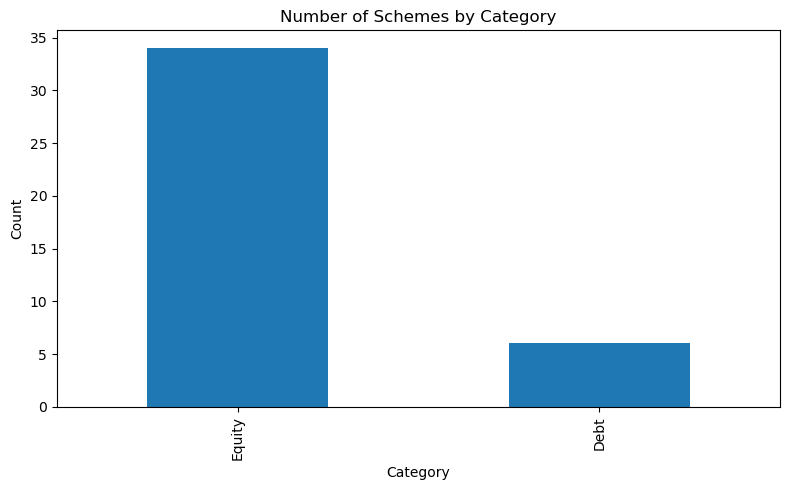

In [5]:
plt.figure(figsize=(8,5))

category_counts.plot(kind='bar')

plt.title("Number of Schemes by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Insight 1

The dataset consists primarily of two major mutual fund categories: Equity and Debt. This provides a balanced foundation for comparing growth-oriented and income-oriented investment products.

In [7]:
scheme[['scheme_name','aum_crore']].head()

,scheme_name,aum_crore
0,SBI Bluechip Fund - Regular Plan - Growth,14288
1,SBI Bluechip Fund - Direct Plan - Growth,1231
2,SBI Small Cap Fund - Regular Plan - Growth,19259
3,SBI Small Cap Fund - Direct Plan - Growth,36061
4,SBI Magnum Gilt Fund - Regular Plan - Growth,24101


In [9]:
top_aum = scheme.sort_values(
    by='aum_crore',
    ascending=False
).head(10)

top_aum[['scheme_name','aum_crore']]

,scheme_name,aum_crore
35,Mirae Asset Emerging Bluechip Fund - Regular -...,49046
21,Kotak Emerging Equity Fund - Regular - Growth,47469
17,Nippon India Small Cap Fund - Regular - Growth,43630
37,DSP Top 100 Equity Fund - Regular - Growth,41828
32,UTI Mid Cap Fund - Regular - Growth,41728
29,ABSL Small Cap Fund - Regular - Growth,41613
11,ICICI Pru Bluechip Fund - Direct - Growth,41553
16,Nippon India Large Cap Fund - Direct - Growth,39475
14,ICICI Pru Liquid Fund - Regular - Growth,39116
30,ABSL Liquid Fund - Regular - Growth,38995


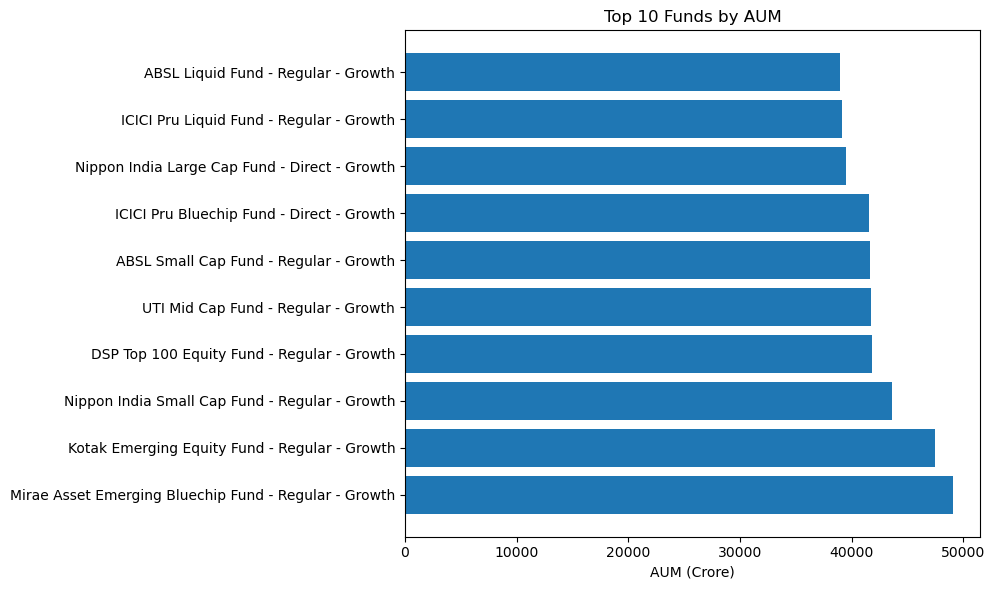

In [10]:
plt.figure(figsize=(10,6))

plt.barh(
    top_aum['scheme_name'],
    top_aum['aum_crore']
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.tight_layout()

plt.show()

## Insight 2

A small number of schemes account for a significant share of total assets under management (AUM), indicating concentration of investor capital in a few large funds.

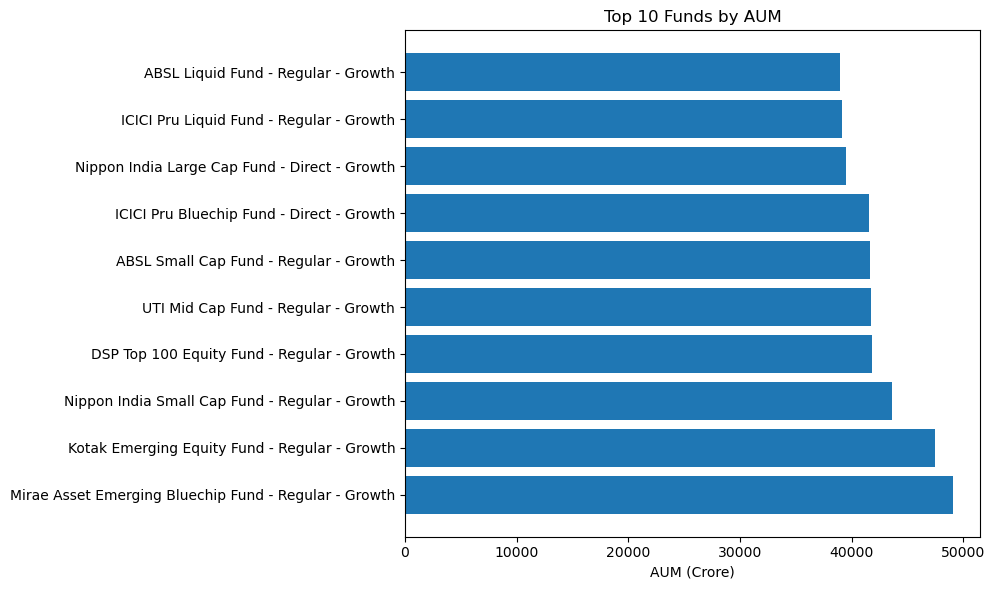

In [12]:
plt.figure(figsize=(10,6))

plt.barh(
    top_aum['scheme_name'],
    top_aum['aum_crore']
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.tight_layout()

plt.savefig("../reports/top_10_funds_by_aum.png")

plt.show()

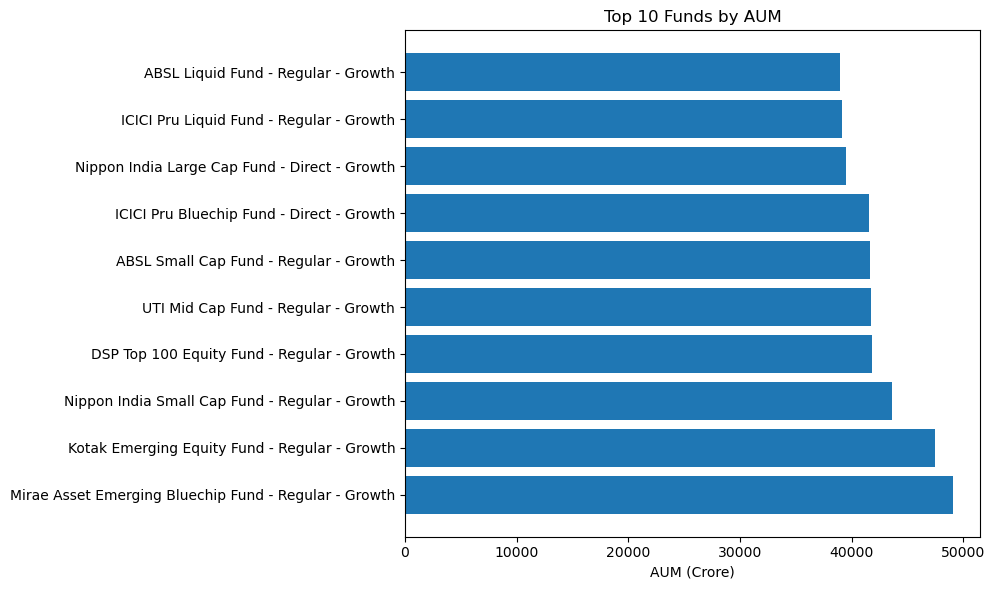

In [14]:
plt.figure(figsize=(10,6))

plt.barh(
    top_aum['scheme_name'],
    top_aum['aum_crore']
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.tight_layout()

plt.savefig("../reports/top_10_funds_by_aum.png")

plt.show()

In [16]:
scheme['morningstar_rating'].value_counts()

morningstar_rating
5    17
4    16
3     7
Name: count, dtype: int64

In [18]:
rating_counts = scheme['morningstar_rating'].value_counts().sort_index()

rating_counts

morningstar_rating
3     7
4    16
5    17
Name: count, dtype: int64

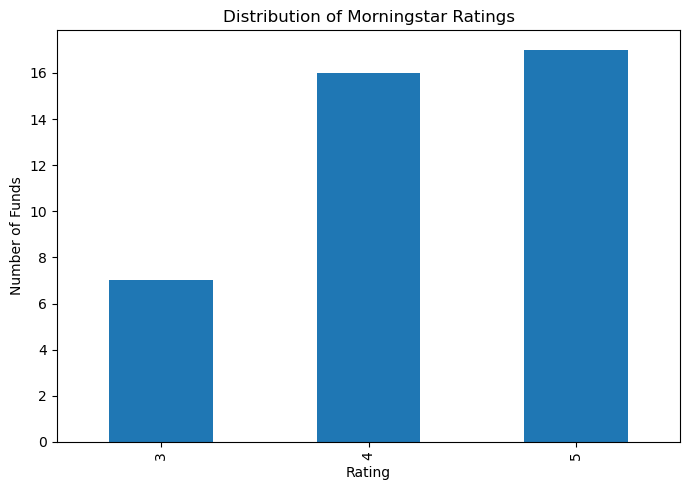

In [19]:
plt.figure(figsize=(7,5))

rating_counts.plot(kind='bar')

plt.title("Distribution of Morningstar Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/morningstar_rating_distribution.png")

plt.show()

## Insight 3

Most funds in the dataset have high Morningstar ratings, with ratings of 4 and 5 accounting for the majority of schemes. This suggests that the dataset is dominated by relatively well-performing and highly rated mutual funds.

In [21]:
scheme[['return_3yr_pct', 'sharpe_ratio']].head()

,return_3yr_pct,sharpe_ratio
0,12.36,0.88
1,11.30,0.81
2,23.39,0.94
3,23.14,0.93
4,6.07,1.52


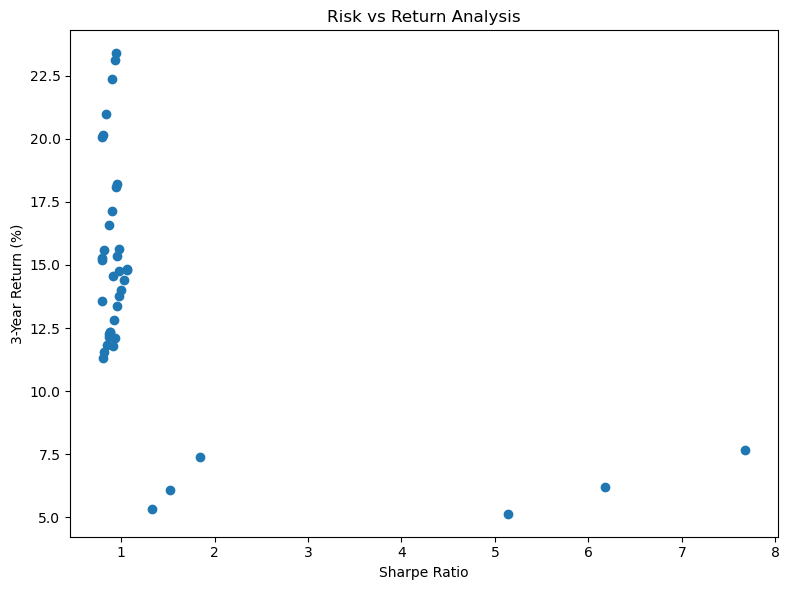

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    scheme['sharpe_ratio'],
    scheme['return_3yr_pct']
)

plt.title("Risk vs Return Analysis")
plt.xlabel("Sharpe Ratio")
plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports/risk_vs_return.png")

plt.show()

## Insight 4

The scatter plot shows the relationship between risk-adjusted performance (Sharpe Ratio) and 3-year returns. Funds located toward the upper-right region of the chart generally provide higher returns along with better risk-adjusted performance.

In [24]:
print(scheme.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


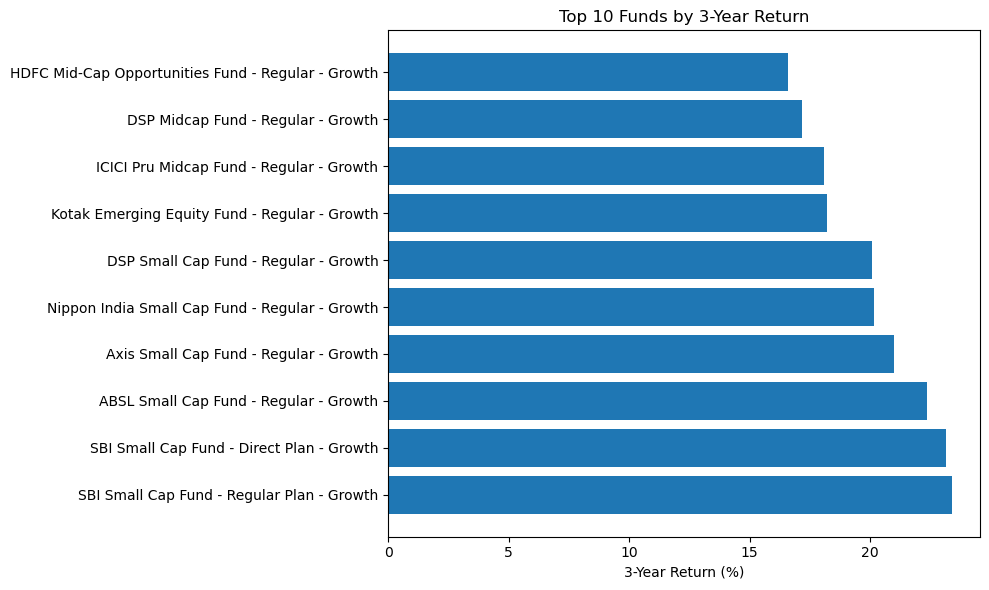

In [25]:
top_returns = scheme.sort_values(
    by='return_3yr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_returns['scheme_name'],
    top_returns['return_3yr_pct']
)

plt.title("Top 10 Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports/top_10_returns.png")

plt.show()

## Insight 5

The highest-performing schemes significantly outperform the average fund in the dataset. This highlights the importance of fund selection when building a mutual fund portfolio.

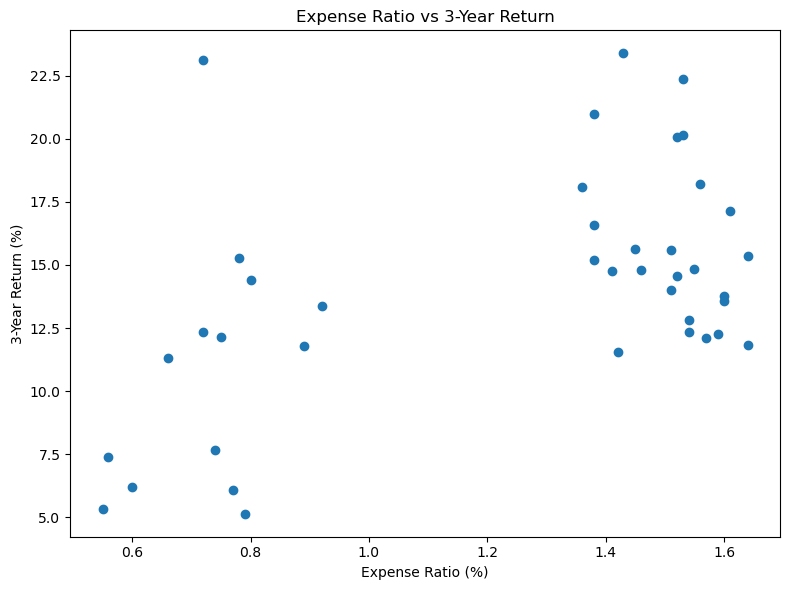

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    scheme['expense_ratio_pct'],
    scheme['return_3yr_pct']
)

plt.title("Expense Ratio vs 3-Year Return")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports(expense_vs_return.png")

plt.show()

## Insight 6

The relationship between expense ratio and returns is not strictly linear. Higher expenses do not automatically translate into better performance, emphasizing the need for careful fund evaluation.

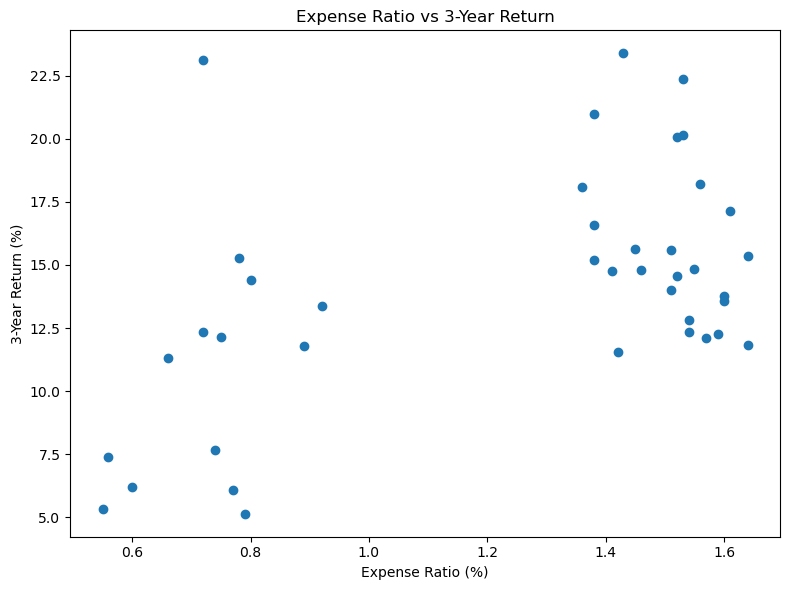

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    scheme['expense_ratio_pct'],
    scheme['return_3yr_pct']
)

plt.title("Expense Ratio vs 3-Year Return")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports/expense_vs_return.png")

plt.show()

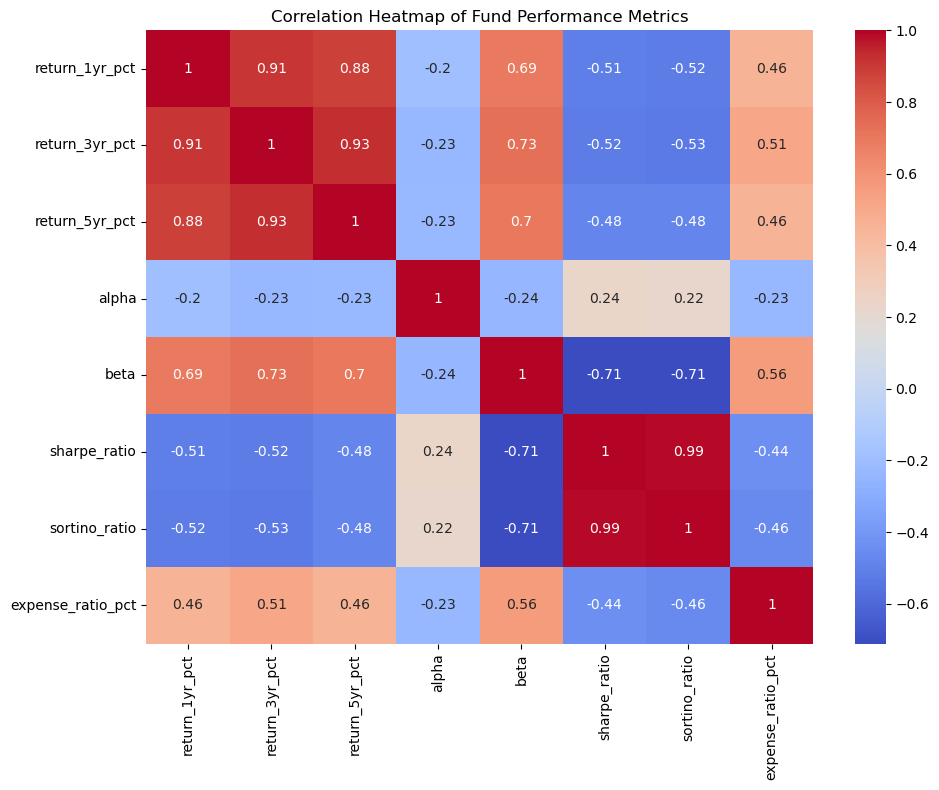

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'expense_ratio_pct'
]

corr_matrix = scheme[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Fund Performance Metrics")

plt.tight_layout()

plt.savefig("../reports/correlation_heatmap.png")

plt.show()

## Insight 7

The heatmap highlights relationships between performance and risk metrics. Positive correlations indicate metrics that tend to move together, while negative correlations reveal trade-offs between fund characteristics.

In [31]:
scheme['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

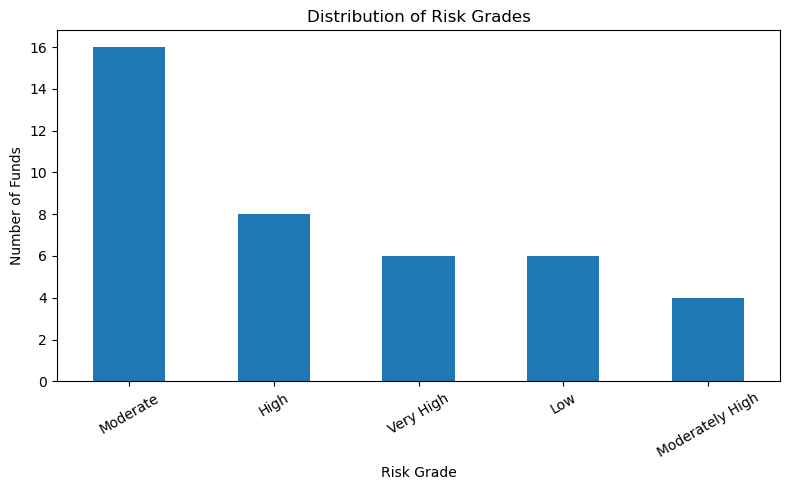

In [32]:
risk_counts = scheme['risk_grade'].value_counts()

plt.figure(figsize=(8,5))

risk_counts.plot(kind='bar')

plt.title("Distribution of Risk Grades")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("../reports/risk_grade_distribution.png")

plt.show()

## Insight 8

Most schemes fall within the Moderate and High risk categories. A smaller proportion of funds belong to the Low and Very High risk segments, indicating a concentration of investment products in the middle of the risk spectrum.

In [33]:
investor['age_group'].value_counts()

NameError: name 'investor' is not defined

In [35]:
import pandas as pd

investor_transactions = pd.read_csv("../data/investor_transactions.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/investor_transactions.csv'

In [37]:
import os

os.listdir("../data")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Bluestock_MF_Capstone_Project.pdf',
 'cleaned_investor_transactions.csv',
 'cleaned_nav_history.csv',
 'live_nav_125497.csv',
 'mutual_fund.db']

In [39]:
investor = pd.read_csv("../data/08_investor_transactions.csv")

In [41]:
investor.shape

(32778, 13)

In [43]:
investor['age_group'].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

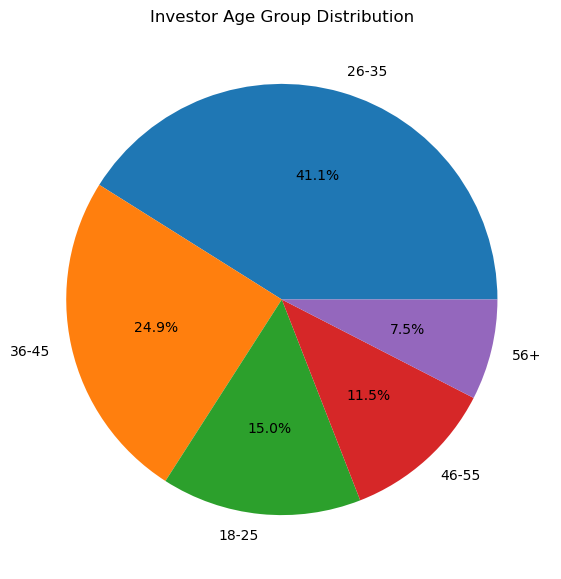

In [44]:
age_counts = investor['age_group'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/age_group_distribution.png")

plt.show()

## Insight 9

Investors aged 26–35 form the largest segment of the customer base, indicating strong participation from early-career professionals in mutual fund investments.

In [46]:
investor['gender'].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

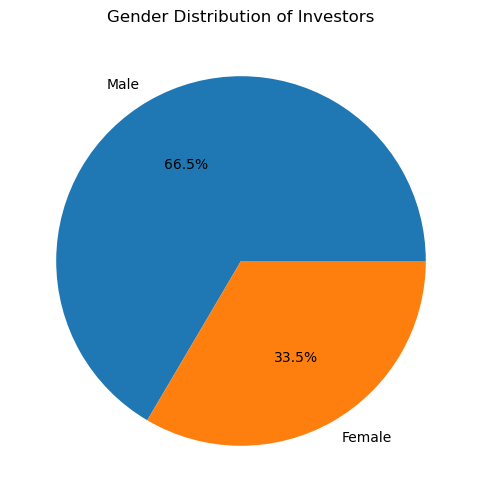

In [47]:
gender_counts = investor['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution of Investors")

plt.savefig("../reports/gender_distribution.png")

plt.show()

## Insight 10

Male investors account for approximately two-thirds of all transactions, while female participation represents about one-third of the investor base.

In [49]:
investor['city_tier'].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

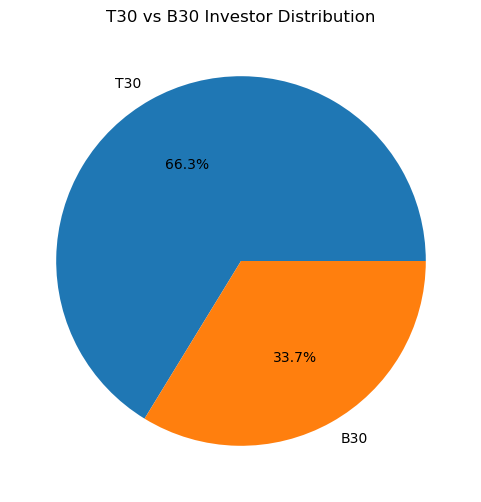

In [50]:
city_counts = investor['city_tier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig("../reports/city_tier_distribution.png")

plt.show()

## Insight 11

A majority of investors belong to T30 cities, indicating that mutual fund participation remains concentrated in major urban centers. However, B30 cities also contribute a significant share of investor activity.

In [51]:
aum = pd.read_csv("../data/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/05_category_inflows.csv")
folio = pd.read_csv("../data/06_industry_folio_count.csv")
holdings = pd.read_csv("../data/09_portfolio_holdings.csv")

In [53]:
print(aum.columns.tolist())
print(sip.columns.tolist())
print(category.columns.tolist())
print(folio.columns.tolist())
print(holdings.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


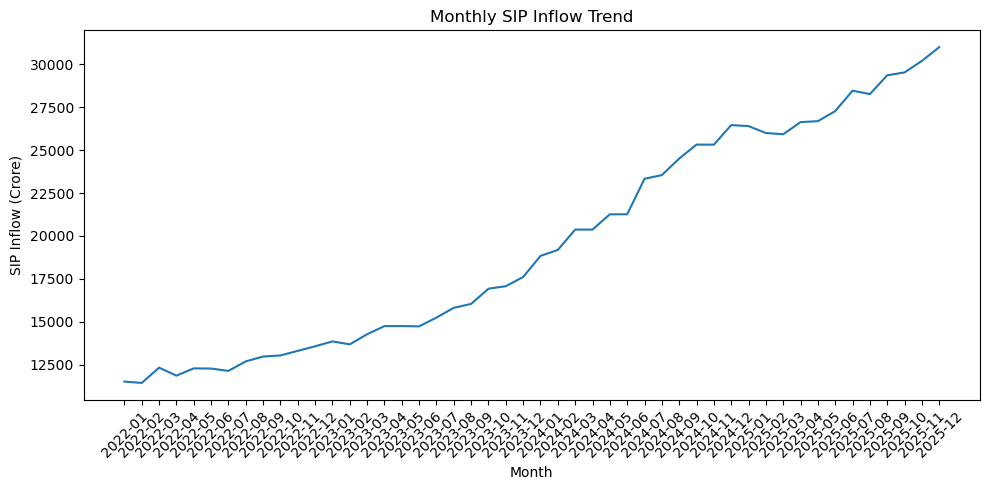

In [55]:
plt.figure(figsize=(10,5))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore']
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/monthly_sip_inflow_trend.png")

plt.show()

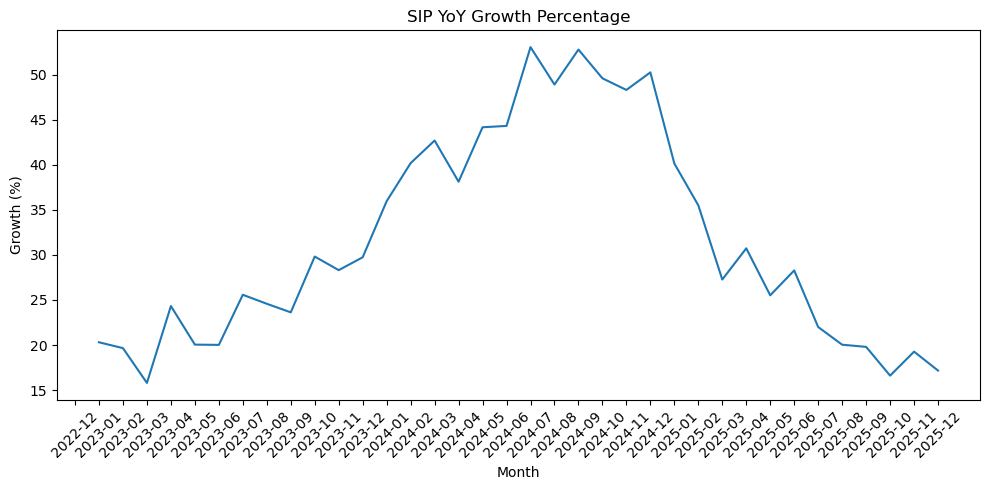

In [57]:
plt.figure(figsize=(10,5))

plt.plot(
    sip['month'],
    sip['yoy_growth_pct']
)

plt.title("SIP YoY Growth Percentage")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/sip_yoy_growth.png")

plt.show()

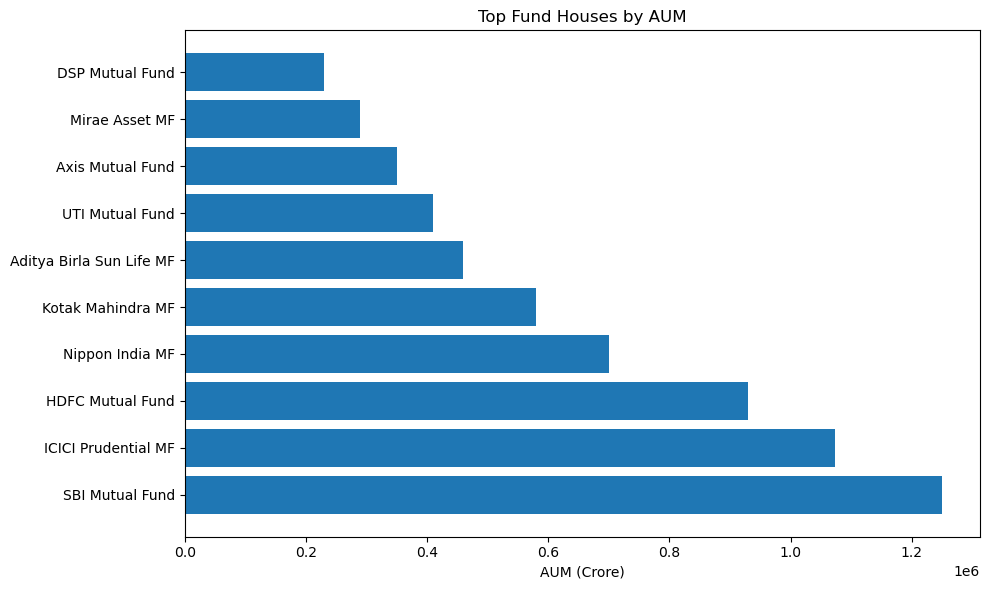

In [59]:
latest_aum = aum.sort_values(
    'date'
).groupby('fund_house').tail(1)

top_aum = latest_aum.sort_values(
    'aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_aum['fund_house'],
    top_aum['aum_crore']
)

plt.title("Top Fund Houses by AUM")
plt.xlabel("AUM (Crore)")

plt.tight_layout()

plt.savefig("../reports/top_fund_houses_aum.png")

plt.show()

In [61]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


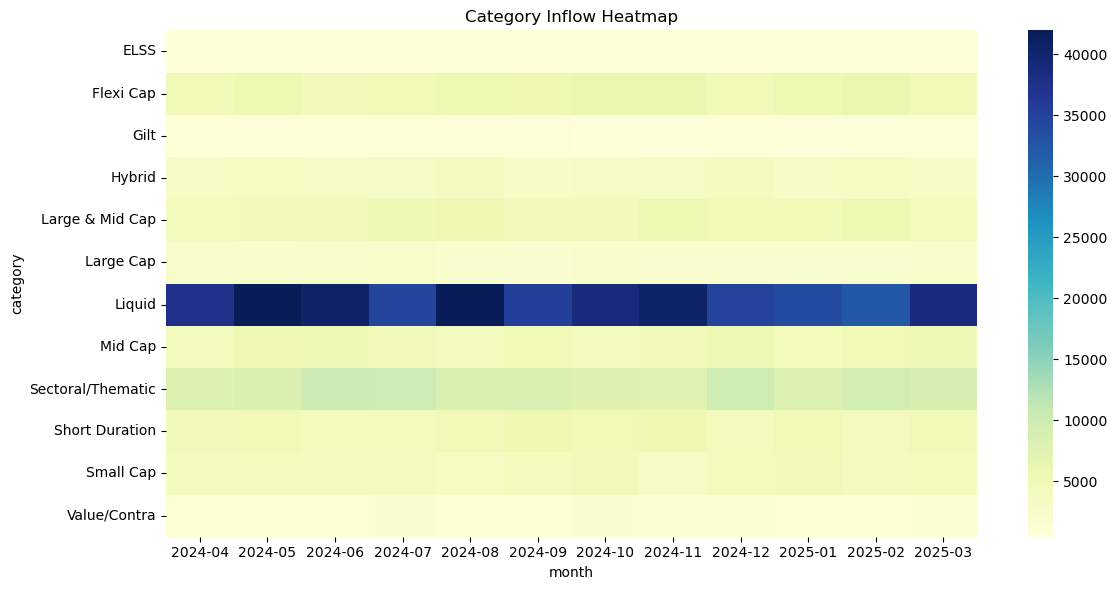

In [63]:
import seaborn as sns

pivot_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_data,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()

plt.savefig("../reports/category_inflow_heatmap.png")

plt.show()

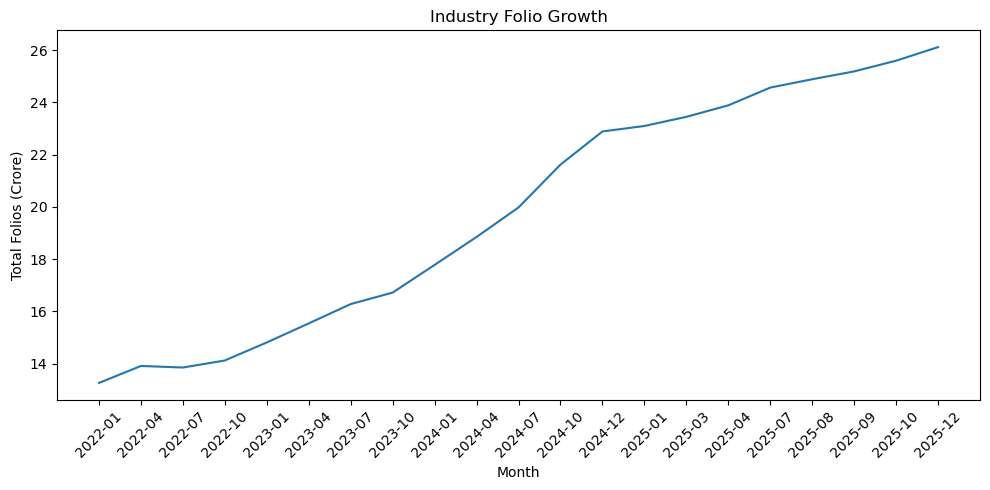

In [64]:
plt.figure(figsize=(10,5))

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/industry_folio_growth.png")

plt.show()